# Predicción de atrasos en operaciones logísticas

## Resumen del proyecto

Este proyecto desarrolla un modelo de Machine Learning para **predecir atrasos en operaciones logísticas** y generar alertas tempranas sobre posibles casos críticos.

El objetivo es anticipar atrasos en la atención de camiones utilizando variables operacionales como:
- Semana del año
- Hora programada
- Empresa transportista
- Tipo de carga
- Tipo de operación

## Dataset

El dataset utilizado contiene **35.250 operaciones logísticas simuladas**, incluyendo información sobre programación, tipo de carga y tiempos de atraso.

## Metodología

El proyecto sigue las siguientes etapas:

1. Análisis exploratorio de datos (EDA)
2. Feature Engineering
3. Entrenamiento de distintos modelos de Machine Learning
4. Evaluación y selección del mejor modelo
5. Optimización del umbral para detectar atrasos críticos
6. Interpretabilidad del modelo mediante SHAP

## Resultados

El modelo **XGBoost** obtuvo el mejor desempeño predictivo, logrando:

- **MAE:** ~11–12 minutos
- **R²:** ~0.57


## Aplicación en el negocio

El modelo permite generar **alertas tempranas de atrasos**, lo que podría utilizarse para:

- priorizar operaciones críticas
- anticipar congestión operacional
- mejorar la planificación logística

In [105]:
#Imports
import os

#Manipulación de datos
import numpy as np
import pandas as pd

#Vidualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

#Modelado
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import recall_score, precision_score
from xgboost import XGBRegressor

#Interpretabilidad
import shap




RANDOM_STATE = 2026
sns.set_theme(style="whitegrid")

* Funciones auxiliares:

In [102]:
def hhmmss_to_minutes(s: str) -> int:
    "HH:MM:SS -> minutos del día"
    h, m, _ = s.split(":")
    return int(h) * 60 + int(m)

def minutes_to_hhmmss_day(m: int) -> str:
    "minutos del día -> HH:MM:SS (ajustado a 24h)"
    m = int(m) % 1440
    h = m // 60
    mm = m % 60
    return f"{h:02d}:{mm:02d}:00"

def minutos_a_hhmmss(mins: float) -> str:
    "minutos -> HH:MM:SS (puede ser negativo)"
    sign = "-" if mins < 0 else ""
    mins = abs(int(round(mins)))
    h = mins // 60
    m = mins % 60
    return f"{sign}{h:02d}:{m:02d}:00"

def clasificar_riesgo(x: float) -> str:
    if x >= 30:
        return "Alto"
    elif x >= 15:
        return "Medio"
    return "Bajo"

In [103]:
# Cargar el dataset
dataset = pd.read_csv("../data/raw/logistics_24h_hhmmss.csv")
dataset.head()

,semana,empresa,patente,tipo_operacion,tipo_carga,hora_programada,hora_ingreso_real,hora_inicio_operacion,hora_fin_operacion,minutos_atraso
0,30,GlaciarNova Freight,TRK-043,Despacho,Carga Suelta,03:50:00,04:41:00,05:00:00,06:10:00,51.42
1,6,QuantaRuta Logistics,TRK-030,Recepcion,Pallet,07:47:00,07:37:00,07:53:00,08:58:00,-9.73
2,27,BorealDock Supply,TRK-003,Despacho,Pallet,07:55:00,07:48:00,08:01:00,08:37:00,-7.24
3,15,KryoKargo Integrado,TRK-052,Despacho,Carga Suelta,08:39:00,08:36:00,08:53:00,10:31:00,-2.90
4,23,Altacima Coldhaul,TRK-002,Despacho,Pallet,09:44:00,10:28:00,10:41:00,11:19:00,43.90


* Calidad de datos:

In [104]:
print("Shape:", dataset.shape)
display(dataset.info())
display(dataset.describe(include="all"))

print("\nNulos:")
display(dataset.isnull().sum())

print("\nDuplicados:", dataset.duplicated().sum())

Shape: (35250, 10)
<class 'pandas.DataFrame'>
RangeIndex: 35250 entries, 0 to 35249
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   semana                 35250 non-null  int64  
 1   empresa                35250 non-null  str    
 2   patente                35250 non-null  str    
 3   tipo_operacion         35250 non-null  str    
 4   tipo_carga             35250 non-null  str    
 5   hora_programada        35250 non-null  str    
 6   hora_ingreso_real      35250 non-null  str    
 7   hora_inicio_operacion  35250 non-null  str    
 8   hora_fin_operacion     35250 non-null  str    
 9   minutos_atraso         35250 non-null  float64
dtypes: float64(1), int64(1), str(8)
memory usage: 2.7 MB


None

,semana,empresa,patente,tipo_operacion,tipo_carga,hora_programada,hora_ingreso_real,hora_inicio_operacion,hora_fin_operacion,minutos_atraso
count,35250.000000,35250,35250,35250,35250,35250,35250,35250,35250,35250.000000
unique,NaN,15,80,2,2,1440,1440,1440,1440,NaN
top,NaN,Nivalis CargoWorks,TRK-060,Despacho,Pallet,14:38:00,11:33:00,12:05:00,18:25:00,NaN
freq,NaN,3439,485,19462,24659,54,56,65,60,NaN
mean,26.416823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.310207
std,15.073271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.536961
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-49.090000
25%,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.412500
50%,26.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.640000
75%,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.540000



Nulos:


semana                   0
empresa                  0
patente                  0
tipo_operacion           0
tipo_carga               0
hora_programada          0
hora_ingreso_real        0
hora_inicio_operacion    0
hora_fin_operacion       0
minutos_atraso           0
dtype: int64


Duplicados: 0


# EDA

## Distribución de minutos de atraso
La distribución de minutos de atraso presenta una forma aproximadamente normal con ligera asimetría positiva.

La mayoría de las operaciones se concentran entre 0 y 40 minutos de atraso, con un promedio cercano a los 20 minutos.

Se observan eventos extremos superiores a 80 minutos, los cuales representan riesgos operacionales significativos.

La presencia de cola derecha y valores extremos justifica el uso de modelos no lineales capaces de capturar comportamientos no simétricos.

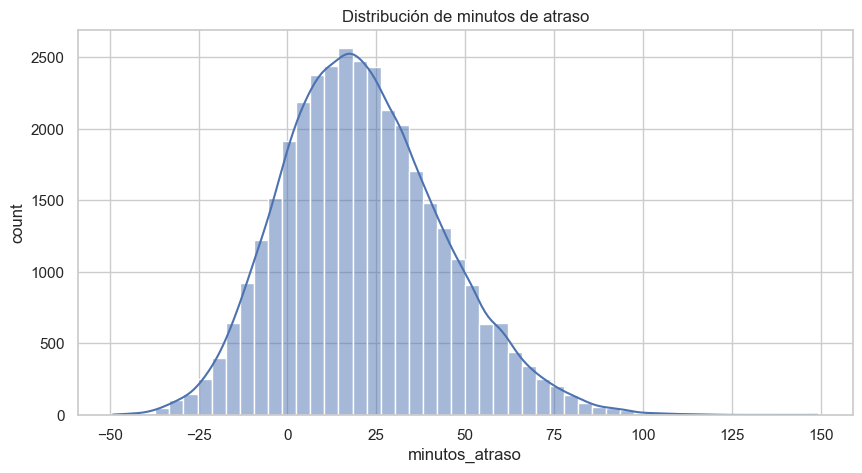

In [5]:
#Distribución de minutos de atraso
plt.figure(figsize=(10,5))
sns.histplot(dataset["minutos_atraso"], bins=50, kde=True)
plt.title("Distribución de minutos de atraso")
plt.xlabel("minutos_atraso")
plt.ylabel("count")
plt.show()


In [6]:
# % de llegadas tarde (Global)
dataset["llego_tarde"] = dataset["minutos_atraso"] > 0
tasa_global = dataset["llego_tarde"].mean() * 100
print(f"Tasa global de llegadas tarde: {tasa_global:.2f}%")

Tasa global de llegadas tarde: 82.91%


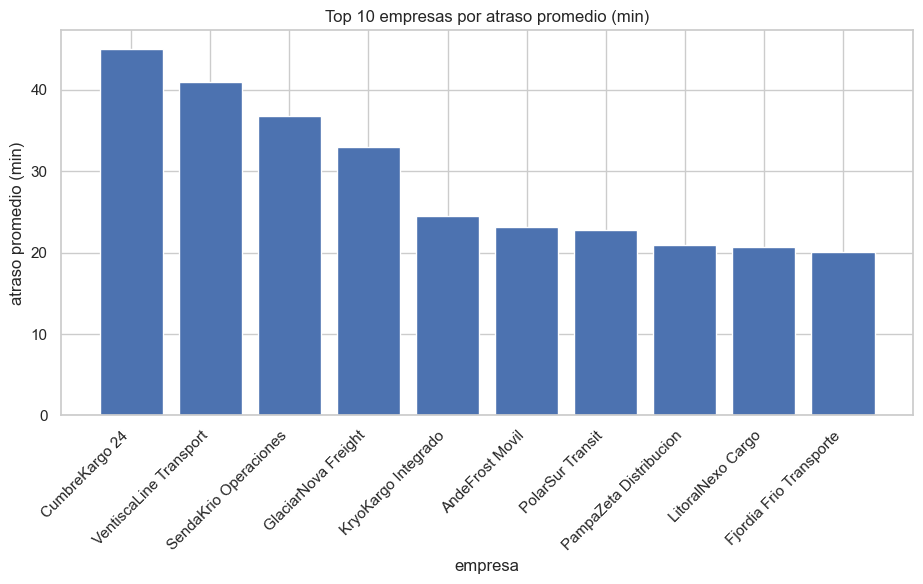

In [7]:
# Top 10 empresas por atraso promedio
top_emp = dataset.groupby("empresa")["minutos_atraso"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top_emp.index, top_emp.values)
plt.title("Top 10 empresas por atraso promedio (min)")
plt.xlabel("empresa")
plt.ylabel("atraso promedio (min)")
plt.xticks(rotation=45, ha="right")
plt.show()

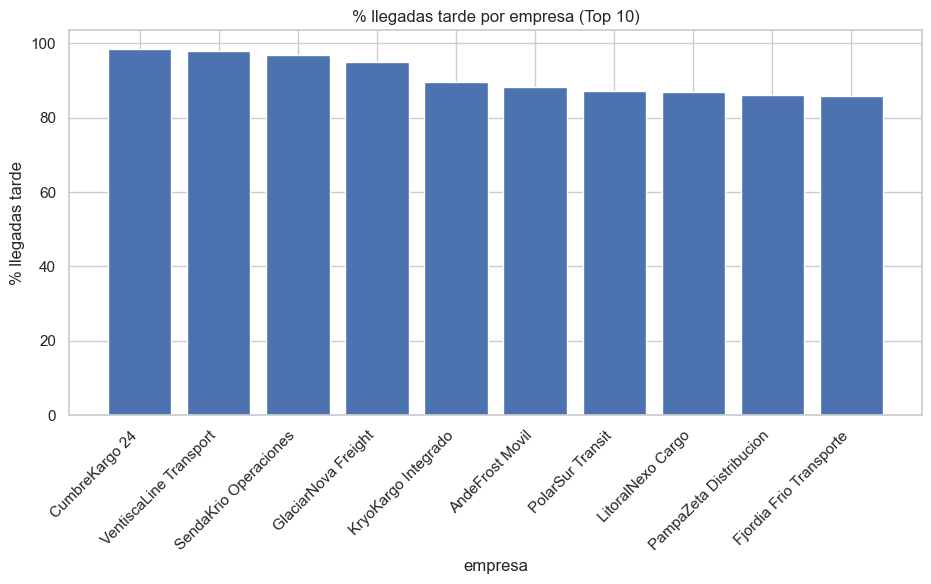

In [8]:
#Llegadas tarde por empresa (Top 10)
top_tasa = (dataset.groupby("empresa")["llego_tarde"].mean() * 100).sort_values(ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top_tasa.index, top_tasa.values)
plt.title("% llegadas tarde por empresa (Top 10)")
plt.xlabel("empresa")
plt.ylabel("% llegadas tarde")
plt.xticks(rotation=45, ha="right")
plt.show()

## Empresas con Mayor Impacto Operacional

No todas las empresas afectan de la misma manera la operación logística.

Para identificar cuáles generan mayor problema, se construyó un indicador llamado **Impacto Operacional**, que combina dos factores clave:

- **Tasa de incumplimiento**: porcentaje de operaciones que llegan tarde.
- **Atraso promedio cuando se atrasan**: cantidad promedio de minutos de atrasos considerando solo las operaciones tardías.

El indicador se calcula de la siguiente forma:

Impacto = Tasa de incumplimiento × Atraso promedio (operaciones tardías)

Donde:

Tasa de incumplimiento = Operaciones tardías / Total de operaciones

Este cálculo permite combinar:

- La **frecuencia del problema** (qué tan seguido ocurre)
- La **gravedad del problema** (qué tan grande es cuando ocurre)

De esta manera, no solo se observa quién tiene más atrasos, sino quién genera mayor efecto total en la operación.

Por ejemplo, una empresa puede atrasarse pocas veces pero con atrasos muy largos, mientras otra puede atrasarse muchas veces pero solo algunos minutos.  
El indicador equilibra ambos factores y ayuda a priorizar aquellas empresas que realmente representan mayor riesgo operativo.

En términos prácticos, este análisis permite enfocar acciones correctivas donde el beneficio potencial es mayor.

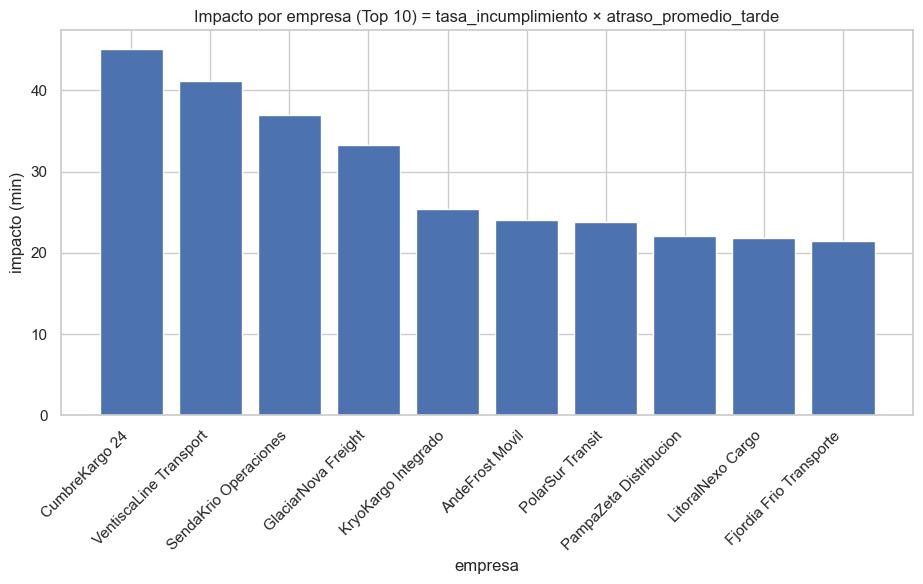

,total_ops,tasa_inc,atraso_prom_tarde,impacto
empresa,,,,
CumbreKargo 24,1057,0.984863,45.818012,45.124456
VentiscaLine Transport,1731,0.977470,42.050366,41.102958
SendaKrio Operaciones,2159,0.968504,38.226777,37.022784
GlaciarNova Freight,2804,0.950071,35.076062,33.324761
KryoKargo Integrado,2446,0.894113,28.449781,25.437314
AndeFrost Movil,2485,0.881690,27.318539,24.086487
PolarSur Transit,2153,0.872271,27.259542,23.777715
PampaZeta Distribucion,2090,0.860766,25.633013,22.064014
LitoralNexo Cargo,2170,0.867742,25.091004,21.772516


In [ ]:
#Impacto por empresa = tasa_incumplimiento × atraso_promedio_tarde
def mean_if_tarde(s):
    s = s[s > 0]
    return float(s.mean()) if len(s) else 0.0

perf = dataset.groupby("empresa").agg(
    total_ops=("minutos_atraso","size"),
    tasa_inc=("llego_tarde","mean"),
    atraso_prom_tarde=("minutos_atraso", mean_if_tarde),
)
perf["impacto"] = perf["tasa_inc"] * perf["atraso_prom_tarde"]
top_impacto = perf.sort_values("impacto", ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top_impacto.index, top_impacto["impacto"].values)
plt.title("Impacto por empresa (Top 10) = tasa_incumplimiento × atraso_promedio_tarde")
plt.xlabel("empresa")
plt.ylabel("impacto (min)")
plt.xticks(rotation=45, ha="right")
plt.show()

top_impacto

## Atraso promedio por Empresa y Hora programada

El heatmap muestra cómo varía el atraso promedio según la empresa y la hora programada.

Se observa un patrón consistente de aumento en los minutos de atraso a partir de las 18:00 horas, lo que sugiere posibles efectos de congestión, menor dotación operativa o acumulación de atrasos durante la jornada.

Asimismo, no todas las empresas presentan el mismo comportamiento: algunas mantienen niveles bajos de atraso de forma relativamente estable, mientras que otras muestran incrementos significativos en horarios específicos.

Este análisis confirma que el atraso no es un fenómeno homogéneo, sino que depende tanto del proveedor como del contexto horario, lo que refuerza la necesidad de modelos predictivos capaces de capturar interacciones no lineales entre variables.

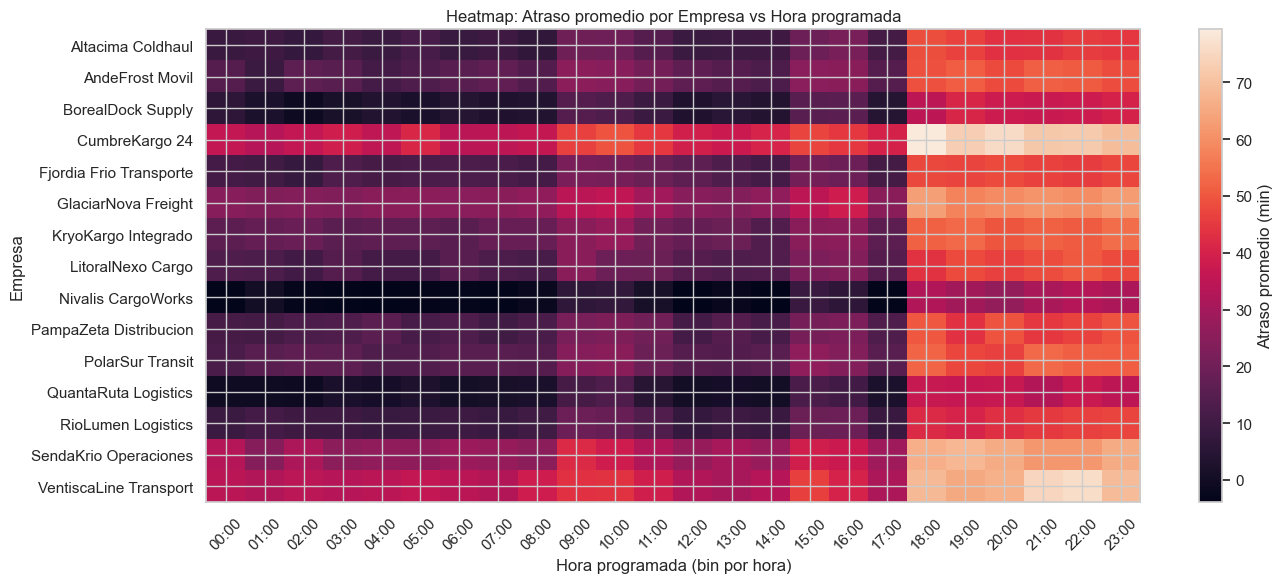

In [ ]:
# Análisis de carga operacional (número de camiones) y atraso promedio por hora
# Del auxiliar: HH:MM:SS -> minuto del día
def hhmmss_to_min(s: str) -> int:
    h, m, _ = s.split(":")
    return int(h)*60 + int(m)

dataset_eda = dataset.copy()
dataset_eda["hora_programada_min"] = dataset_eda["hora_programada"].apply(hhmmss_to_min)
dataset_eda["hora_bin"] = (dataset_eda["hora_programada_min"] // 60)  #bins por hora (0 a 23)

# pivot: filas empresa, columnas hora, valores atraso promedio
pivot = dataset_eda.pivot_table(
    index="empresa",
    columns="hora_bin",
    values="minutos_atraso",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
plt.imshow(pivot, aspect="auto")  # aspect="auto" para ajustar el tamaño de las celdas
plt.colorbar(label="Atraso promedio (min)")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.title("Heatmap: Atraso promedio por Empresa vs Hora programada")
plt.xlabel("Hora programada (bin por hora)")
plt.ylabel("Empresa")
plt.tight_layout()
plt.show()

## Relación entre carga operacional y atraso promedio

El análisis conjunto del volumen de camiones programados y del atraso promedio por hora permite observar la relación entre la carga operacional y el comportamiento de los atrasos.

Durante la madrugada (00:00–05:00) el número promedio de camiones programados es relativamente bajo, con valores cercanos a 16–17 camiones por hora. En este mismo periodo, el atraso promedio se mantiene en niveles mínimos, lo que sugiere una operación más estable y con menor presión sobre la capacidad del sistema.

A partir de las 06:00 horas se observa un aumento significativo en el volumen de operaciones, alcanzando aproximadamente 40 camiones por hora durante gran parte de la jornada laboral. En paralelo, el atraso promedio comienza a incrementarse y muestra mayor variabilidad, lo que indica que el aumento en la carga operacional puede impactar los tiempos de atención.

El comportamiento más crítico se presenta durante la tarde y noche (18:00–23:00), donde el atraso promedio alcanza sus valores más altos. Este patrón sugiere que la acumulación de operaciones a lo largo del día genera un efecto de congestión en el sistema logístico, aumentando la probabilidad de atrasos en los horarios finales de la jornada.

In [ ]:
# Análisis de carga operacional (número de camiones) y atraso promedio por hora
# extraer hora
dataset_eda["hora"] = pd.to_datetime(dataset_eda["hora_programada"], format="%H:%M:%S").dt.hour

# promedio de camiones por hora
camiones = (
    dataset_eda.groupby(["semana", "hora"])
    .size()
    .reset_index(name="camiones")
)

camiones_prom = (
    camiones.groupby("hora")["camiones"]
    .mean()
    .reset_index()
)
camiones_prom["camiones"]=camiones_prom["camiones"].round(0)
# atraso promedio por hora
atraso_prom = (
    dataset_eda.groupby("hora")["minutos_atraso"]
    .mean()
    .reset_index()
)
atraso_prom["minutos_atraso"]=atraso_prom["minutos_atraso"].round(0)

#gráfico
fig = go.Figure()

# barras (camiones)
fig.add_trace(
    go.Bar(
        x=camiones_prom["hora"],
        y=camiones_prom["camiones"],
        name="Promedio de camiones",
        marker_color="steelblue",
        yaxis="y1"
    )
)

# línea (atraso)
fig.add_trace(
    go.Scatter(
        x=atraso_prom["hora"],
        y=atraso_prom["minutos_atraso"],
        name="Atraso promedio",
        mode="lines+markers",
        line=dict(color="red", width=3),
        yaxis="y2"
    )
)



# doble eje
fig.update_layout(
    title="Carga operacional y atraso promedio por hora",
    xaxis=dict(title="Hora programada"),
    yaxis=dict(
        title="Promedio de camiones",
        side="left"
    ),
    yaxis2=dict(
        title="Atraso promedio (min)",
        overlaying="y",
        side="right"
    ),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

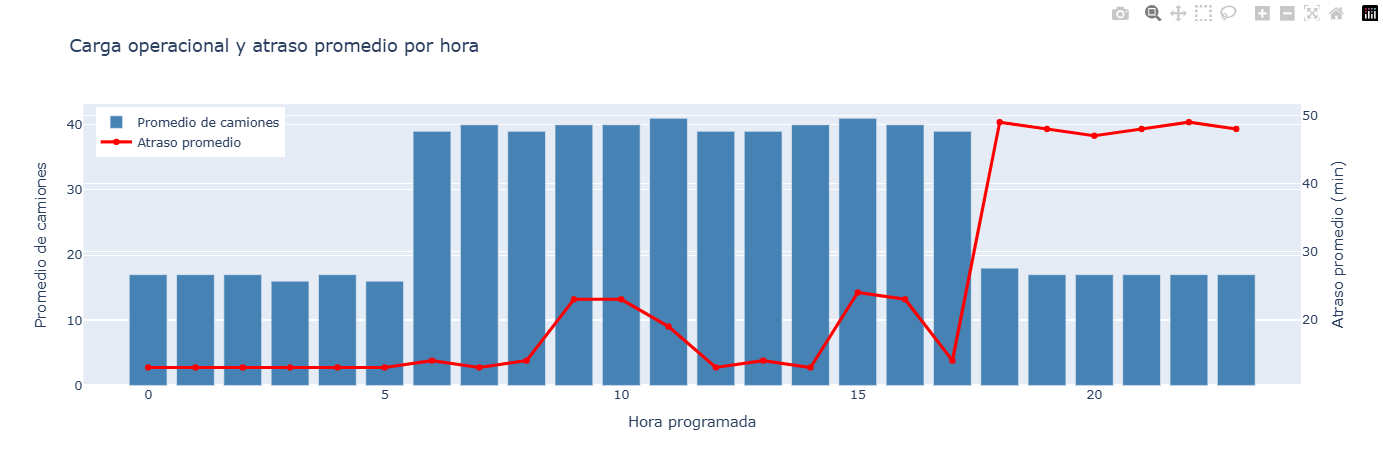

## Distribución del atraso según hora programada

El análisis por bloques horarios revela un patrón claro en el comportamiento de los atrasos operacionales.

Durante la madrugada y primeras horas del día (00:00–08:00), los atrasos tienden a ser menores y presentan una dispersión relativamente baja, lo que sugiere una operación más estable en estos horarios.

A partir de las 08:00 horas comienza a observarse un aumento gradual en la mediana del atraso y en la variabilidad de los tiempos, indicando una mayor acumulación de operaciones a medida que avanza la jornada.

El comportamiento más crítico se presenta entre las **18:00 y 24:00 horas**, donde se registran los mayores niveles de atraso y una dispersión considerablemente mayor, incluyendo múltiples valores extremos.

Este patrón sugiere que **la carga operacional acumulada durante el día impacta directamente en la puntualidad de las operaciones**, aumentando el riesgo de atraso en los bloques horarios de la tarde y noche.

In [65]:
# Análisis de distribución de atrasos por bloque horario
dataset_eda["hora_programada_dt"] = pd.to_datetime(dataset_eda["hora_programada"], format="%H:%M:%S")
dataset_eda["hora"] = dataset_eda["hora_programada_dt"].dt.hour

bins = [0,2,4,6,8,10,12,14,16,18,20,22,24]
labels = ["00 a 02 hrs","02 a 04 hrs","04 a 06 hrs","06 a 08 hrs","08 a 10 hrs","10 a 12 hrs",
          "12 a 14 hrs","14 a 16 hrs","16 a 18 hrs","18 a 20 hrs","20 a 22 hrs","22 a 24 hrs"]

dataset_eda["bloque_hora"] = pd.cut(dataset_eda["hora"], bins=bins, labels=labels, right=False)
dataset_eda["bloque_hora"] = dataset_eda["bloque_hora"].astype(str)

fig = px.box(
    dataset_eda,
    x="bloque_hora",
    y="minutos_atraso",
    color="bloque_hora",
    points="outliers",
    title="Distribución de atrasos por bloque horario",
    category_orders={"bloque_hora": labels}
)

fig.update_layout(
    xaxis_title="Hora programada (bloques de 2 horas)",
    yaxis_title="Minutos de atraso",
    showlegend=False
)

fig.show()

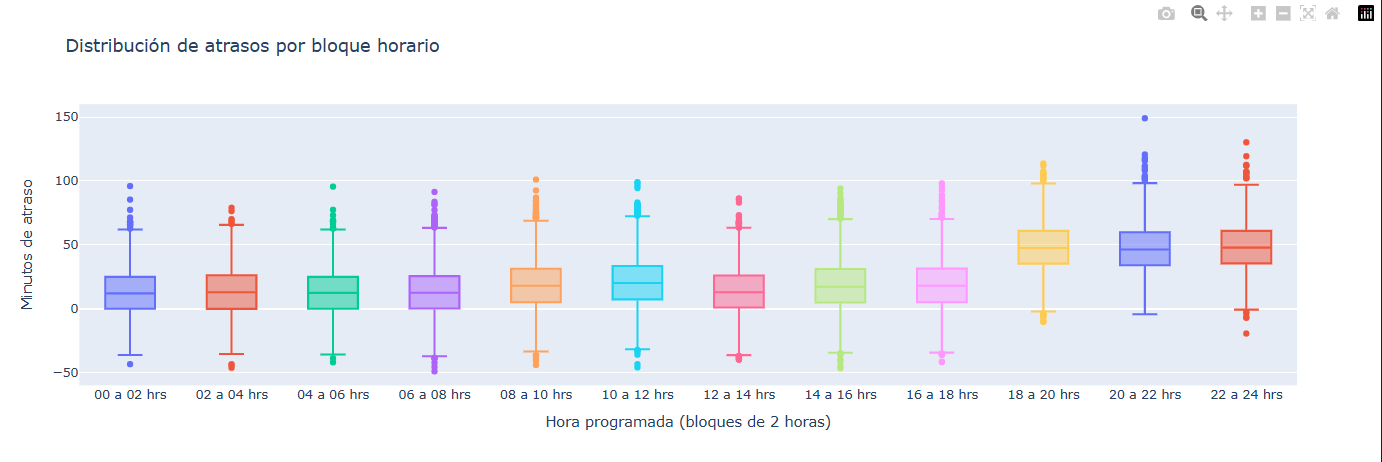

## Conclusiones del Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permitió identificar patrones relevantes en el comportamiento de los atrasos operacionales y comprender mejor los factores que influyen en su variabilidad.

En primer lugar, el análisis de la **distribución de atrasos por hora programada** evidenció diferencias claras a lo largo del día. Durante la madrugada y primeras horas del día (00:00–08:00), los atrasos tienden a ser menores y presentan menor dispersión, lo que sugiere una operación más estable en estos horarios.

A medida que avanza la jornada, particularmente desde las **08:00 horas**, se observa un aumento gradual tanto en la mediana del atraso como en su variabilidad. El comportamiento más crítico se presenta durante la **tarde y primeras horas de la noche (18:00–24:00)**, donde se registran mayores niveles de atraso y una dispersión considerablemente mayor, incluyendo valores extremos.

El análisis del **volumen promedio de camiones programados por hora** aporta una explicación operacional para este comportamiento. Se observa una fuerte concentración de operaciones entre las **06:00 y 17:00 horas**, con un promedio cercano a 40 camiones por hora, lo que indica una alta carga de trabajo durante la jornada principal de operación.

Este alto volumen de operaciones durante el día puede generar **acumulación operacional**, lo que aumenta la probabilidad de atrasos en los horarios posteriores. En este sentido, los mayores atrasos observados durante la tarde y noche podrían estar asociados a la congestión generada por la carga de trabajo acumulada a lo largo de la jornada.

Adicionalmente, el análisis por **empresa y hora programada** evidenció diferencias importantes en el desempeño logístico entre distintos operadores, lo que sugiere que algunos presentan mayor sensibilidad a ciertos horarios de operación.

En conjunto, estos hallazgos muestran que variables como **hora programada, tipo de operación, tipo de carga y empresa** presentan patrones relevantes en la generación de atrasos, lo que justifica su incorporación como variables explicativas en el desarrollo del modelo de predicción.

In [66]:
# Atrasos (minutos) por tipo de operación y tipo de carga
display(dataset_eda.groupby("tipo_operacion")["minutos_atraso"].mean())
display(dataset_eda.groupby("tipo_carga")["minutos_atraso"].mean())
display(dataset_eda.groupby("empresa")["minutos_atraso"].mean())

tipo_operacion
Despacho     18.388163
Recepcion    24.912236
Name: minutos_atraso, dtype: float64

tipo_carga
Carga Suelta    24.084786
Pallet          20.118530
Name: minutos_atraso, dtype: float64

empresa
Altacima Coldhaul          17.552342
AndeFrost Movil            23.116402
BorealDock Supply          11.674585
CumbreKargo 24             45.044428
Fjordia Frio Transporte    20.127736
GlaciarNova Freight        32.978252
KryoKargo Integrado        24.513557
LitoralNexo Cargo          20.713562
Nivalis CargoWorks          5.122809
PampaZeta Distribucion     20.890459
PolarSur Transit           22.768481
QuantaRuta Logistics        9.320179
RioLumen Logistics         16.725823
SendaKrio Operaciones      36.780866
VentiscaLine Transport     40.951999
Name: minutos_atraso, dtype: float64

In [ ]:
# copiamos el dataset para preparar X e y
dt = dataset.copy()

#ya existe hora_programada_min, aseguramos que está
if "hora_programada_min" not in dt.columns:
    dt["hora_programada_min"] = dt["hora_programada"].apply(hhmmss_to_minutes)

X = dt[[
    "semana",
    "empresa",
    "patente",
    "tipo_operacion",
    "tipo_carga",
    "hora_programada_min"]]
y = dt["minutos_atraso"]

In [71]:
# Preprocesamiento: OneHot para categóricas, passthrough para numéricas
categorical = ["empresa", "patente", "tipo_operacion", "tipo_carga"]
numeric = ["semana", "hora_programada_min"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric),])
# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

## Comparación de modelos:

Se evaluaron tres modelos de ML para predecir atrasos en operaciones logisticas:
1. Regresión Lineal
2. Random Forest
3. XGBoost

Cada modelo fue entrenado con el mismo conjunto de datos de entrenamiento y evaluado con el conjunto de datos de test

### Interpretación de las métricas:

Para evaluar el desempeño de los modelos se utilizaron las siguientes métricas:

- **MAE (Mean Absolute Error):** mide el error promedio de las predicciones en minutos.
- **R²:** indica qué proporción de la variabilidad de los datos logra explicar el modelo.

Un menor MAE indica mayor precisión en la predicción de atrasos.
Un mayor valor de R² indica que el modelo captura mejor los patrones presentes en los datos.

In [88]:
# Modelo de regresión lineal
lin = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())])

lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

print("Regresión Lineal")
print("MAE:", mean_absolute_error(y_test, pred_lin))
print("R2 :", r2_score(y_test, pred_lin))

Regresión Lineal
MAE: 13.314159317912733
R2 : 0.44126073839769586


In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [89]:
# Modelo de Random Forest
rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=350,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2 :", r2_score(y_test, pred_rf))

Random Forest
MAE: 12.423644761904763
R2 : 0.5119894062926681


In [ ]:
# Validación cruzada para Random Forest
scores_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)
print("Random Forest CV MAE:", -scores_rf.mean())

Random Forest CV MAE: 12.502718089159066


In [90]:
xgb = Pipeline([
    ("prep", preprocess),
    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("XGBoost Regressor")
print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2 :", r2_score(y_test, pred_xgb))

XGBoost Regressor
MAE: 11.654461986630743
R2 : 0.5715744353966559


### Validación cruzada:

Para evaluar la estabilidad del modelo se aplicó **validación cruzada** con 5 particiones.

El error promedio obtenido mediante validación cruzada fue muy similar al obtenido en el conjunto de prueba, lo que sugiere que el modelo tiene un desempeño consistente y no presenta sobreajuste significativo.

In [91]:
# Validación cruzada para XGBoost
scores_xgb = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("XGB CV MAE:", -scores_xgb.mean())

XGB CV MAE: 11.66724479113231


### Resultados de los modelos:

Los resultados muestran que el modelo **XGBoost** obtuvo el mejor desempeño entre los modelos evaluados.

Este modelo logró el menor error promedio en la predicción de atrasos y el mayor valor de R², lo que indica una mejor capacidad para capturar los patrones presentes en los datos operacionales.

In [92]:
resultados = pd.DataFrame({
    "modelo": ["Linear", "RandomForest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, pred_lin),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_xgb),
    ],
    "R2": [
        r2_score(y_test, pred_lin),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb),
    ]
}).sort_values("MAE")

resultados

,modelo,MAE,R2
2,XGBoost,11.654462,0.571574
1,RandomForest,12.423645,0.511989
0,Linear,13.314159,0.441261


### Selección del modelo:

El modelo **XGBoost** fue seleccionado como el mejor modelo del proyecto.

Esto se debe a que los modelos basados en árboles suelen capturar mejor relaciones no lineales entre las variables, algo común en operaciones logísticas donde múltiples factores pueden afectar los tiempos de llegada.

### Interpretación operacional:

El modelo final logra predecir atrasos con un error promedio cercano a **12 minutos**.

Considerando la variabilidad propia de las operaciones logísticas (tráfico, congestión operativa, tiempos de carga), este nivel de precisión puede ser útil para anticipar posibles atrasos y apoyar la toma de decisiones operacionales.

In [96]:
# Evaluación detallada del mejor modelo (XGBoost)
mae = mean_absolute_error(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2 = r2_score(y_test, pred_xgb)

print("Evaluación del modelo")
print(f"MAE  : {mae:.2f} min")
print(f"RMSE : {rmse:.2f} min")
print(f"R2   : {r2:.3f}")

Evaluación del modelo
MAE  : 11.65 min
RMSE : 14.67 min
R2   : 0.572


## Evaluación de atrasos críticos

Además de evaluar la precisión general del modelo, es importante analizar su capacidad para detectar **atrasos críticos** en la operación.

En este análisis se considera como atraso crítico cualquier operación con un atrasos mayor a **30 minutos**.

Para evaluar este comportamiento se utilizan dos métricas:

- **Recall:** capacidad del modelo para detectar correctamente los atrasos críticos.
- **Precision:** proporción de alertas generadas que realmente corresponden a atrasos críticos.

### Interpretación de resultados

Los resultados muestran que el modelo **XGBoost** obtiene nuevamente el mejor desempeño.

Este modelo presenta:

- El **mayor recall**, lo que indica una mayor capacidad para detectar atrasos críticos.
- La **mayor precisión**, lo que significa que las alertas generadas tienen una mayor probabilidad de corresponder a atrasos reales.

Esto es especialmente importante en un contexto operativo, donde si detectamos con anticipación posibles atrasos nos permitirá tomar acciones preventivas.

In [95]:
# Evaluamos desempeño en casos críticos (>30 min de atraso)
def evaluar_criticos(y_true, y_pred, threshold=30):
    y_true_bin = y_true > threshold
    y_pred_bin = y_pred > threshold


    return (
        recall_score(y_true_bin, y_pred_bin),
        precision_score(y_true_bin, y_pred_bin)
    )

rec_lin = evaluar_criticos(y_test, pred_lin)
rec_rf = evaluar_criticos(y_test, pred_rf)
rec_xgb = evaluar_criticos(y_test, pred_xgb)

comparacion = pd.DataFrame({
    "Modelo": ["Linear", "RandomForest", "XGBoost"],
    "Recall_>30": [rec_lin[0], rec_rf[0], rec_xgb[0]],
    "Precision_>30": [rec_lin[1], rec_rf[1], rec_xgb[1]]
})

comparacion

,Modelo,Recall_>30,Precision_>30
0,Linear,0.585472,0.687787
1,RandomForest,0.629404,0.747417
2,XGBoost,0.623314,0.768777


### Implicación operacional

Detectar atrasos críticos con anticipación puede permitir:

- Reasignar recursos operativos
- Ajustar programación de andenes
- Informar a clientes sobre posibles atrasos
- Reducir congestión en la operación

In [106]:
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


In [107]:
best_model_name = "xgboost"
pred_best = pred_xgb

### Interpretabilidad del modelo (SHAP)

El gráfico SHAP muestra el impacto de cada variable original en las predicciones del modelo.

La **hora programada** aparece como el factor más influyente, indicando que el momento del día en que se agenda un camión tiene un efecto significativo en los minutos de atraso predichos. Valores más altos de esta variable (horas más tardías) tienden a asociarse con impactos positivos en la predicción, lo que sugiere una mayor probabilidad de los atrasos en horarios más avanzados en la jornada.

La **empresa** también presenta una contribución relevante, lo que indica que existen diferencias operativas entre compañías que pueden influir en los tiempos de atención de los camiones.

El **tipo de carga** y la **semana del año** muestran un impacto moderado, sugiriendo que ciertas características operativas o periodos específicos del año pueden generar variaciones en el comportamiento de los atrasos.

Finalmente, el **tipo de operación** tiene una influencia menor en comparación con las otras variables, indicando que su efecto en la predicción del modelo es más limitado.

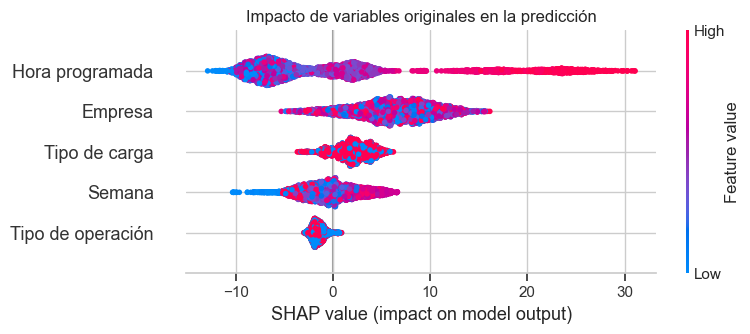

In [78]:
# Transformación y SHAP

X_test_transf = xgb.named_steps["prep"].transform(X_test)
xgb_model = xgb.named_steps["model"]
feature_names = xgb.named_steps["prep"].get_feature_names_out()

X_test_dense = X_test_transf if isinstance(X_test_transf, np.ndarray) else X_test_transf.toarray()
X_test_transf_df = pd.DataFrame(X_test_dense, columns=feature_names)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transf_df)

#Agrupar columnas transformadas por origen

grupos = {
    "Empresa": [c for c in feature_names if "empresa" in c],
    "Tipo de operación": [c for c in feature_names if "tipo_operacion" in c],
    "Tipo de carga": [c for c in feature_names if "tipo_carga" in c],
    "Semana": [c for c in feature_names if "semana" in c],
    "Hora programada": [c for c in feature_names if "hora_programada" in c],
}

# SHAP agrupado
shap_grouped = pd.DataFrame(index=X_test.index)

for nombre, cols in grupos.items():
    if len(cols) > 0:
        idx = [X_test_transf_df.columns.get_loc(c) for c in cols]
        shap_grouped[nombre] = shap_values[:, idx].sum(axis=1)


#Feature values" para el beeswarm

# Para variables numéricas usamos el valor real
# Para categóricas usamos códigos numéricos solo para colorear
features_grouped = pd.DataFrame(index=X_test.index)

features_grouped["Hora programada"] = X_test["hora_programada_min"].values
features_grouped["Semana"] = X_test["semana"].values

features_grouped["Empresa"] = pd.Categorical(X_test["empresa"]).codes
features_grouped["Tipo de operación"] = pd.Categorical(X_test["tipo_operacion"]).codes
features_grouped["Tipo de carga"] = pd.Categorical(X_test["tipo_carga"]).codes

# Aqui ordenamos columnas según importancia promedio
orden = shap_grouped.abs().mean().sort_values(ascending=False).index
shap_grouped = shap_grouped[orden]
features_grouped = features_grouped[orden]


# Beeswarm tipo SHAP

plt.figure()
shap.summary_plot(
    shap_grouped.values,
    features_grouped,
    feature_names=shap_grouped.columns.tolist(),
    show=False
)

plt.title("Impacto de variables originales en la predicción")
plt.tight_layout()
plt.savefig("outputs/figures/shap_grouped_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparación entre valores reales y predichos

El gráfico muestra la relación entre los valores reales de atraso y los valores predichos por el modelo XGBoost.

Idealmente, las observaciones deberían alinearse cerca de una línea diagonal, lo que indicaría que las predicciones del modelo coinciden con los valores reales.

En este caso se observa una clara relación positiva entre ambos valores, lo que sugiere que el modelo logra capturar correctamente la tendencia general de los atrasos en la operación.

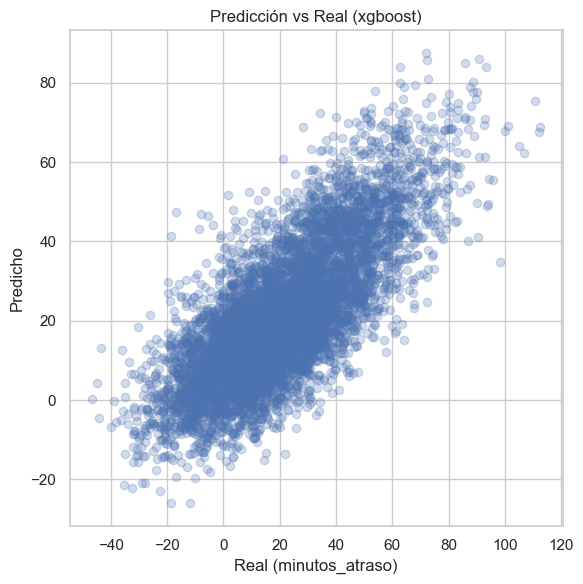

In [110]:
ensure_dir("outputs/figures")

# Pred vs Real
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_best, alpha=0.25)
plt.title(f"Predicción vs Real ({best_model_name})")
plt.xlabel("Real (minutos_atraso)")
plt.ylabel("Predicho")
plt.tight_layout()
plt.savefig(f"outputs/figures/pred_vs_real_{best_model_name}.png", dpi=150)
plt.show()

## Análisis de residuos

El gráfico muestra la distribución de los residuos, que se define como la diferencia entre el valor real y el valor predicho por el modelo.

Una distribución centrada cerca de cero indica que el modelo no presenta un sesgo sistemático en sus predicciones.

En este caso, los residuos se distribuyen principalmente alrededor de cero, lo que sugiere que el modelo mantiene un comportamiento relativamente equilibrado entre sobreestimación y subestimación.

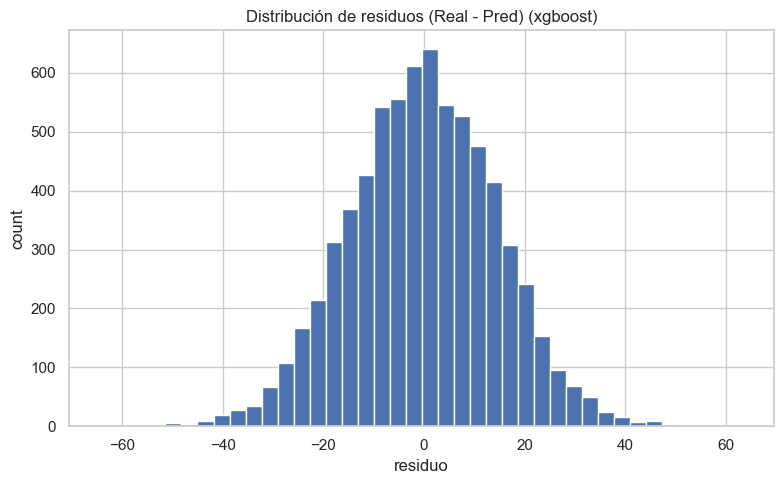

In [109]:
# Residuos
resid = y_test - pred_best
plt.figure(figsize=(8,5))
plt.hist(resid, bins=40)
plt.title(f"Distribución de residuos (Real - Pred) ({best_model_name})")
plt.xlabel("residuo")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(f"outputs/figures/residuos_{best_model_name}.png", dpi=150)
plt.show()

## Análisis del umbral de alerta

En el análisis anterior se consideró como atraso crítico cualquier operación con más de **30 minutos de atraso**.

Sin embargo, desde un punto de vista operativo puede ser útil ajustar el **umbral de alerta del modelo** para mejorar su capacidad de detección.

Por esta razón se realiza un barrido de distintos valores de umbral de predicción para analizar cómo cambian las métricas de **recall** y **precision**.

### Interpretación del barrido de umbral

La tabla muestra cómo varía el desempeño del modelo cuando se modifica el umbral utilizado para generar alertas.

Se observa el comportamiento esperado:

- Umbrales **más bajos** generan más alertas y aumentan el **recall**.
- Umbrales **más altos** reducen el número de alertas pero aumentan la **precision**.

Esto refleja un trade-off entre detectar más casos críticos o reducir la cantidad de falsas alarmas.

In [81]:
#Umbral vs Recall/Precision
def threshold_report(y_true, y_pred, pred_threshold, real_threshold=30):
    y_true_bin = y_true > real_threshold
    y_pred_bin = y_pred > pred_threshold
    return {
        "Umbral_pred": pred_threshold,
        "Alertas_generadas": int(y_pred_bin.sum()),
        "Criticos_reales": int(y_true_bin.sum()),
        "Recall": recall_score(y_true_bin, y_pred_bin),
        "Precision": precision_score(y_true_bin, y_pred_bin),
    }

# Barrido
thresholds = np.arange(15, 45, 2)
grid = pd.DataFrame([threshold_report(y_test, pred_best, t) for t in thresholds])
grid

,Umbral_pred,Alertas_generadas,Criticos_reales,Recall,Precision
0,15,4209,2299,0.933449,0.509860
1,17,3868,2299,0.909961,0.540848
2,19,3487,2299,0.879078,0.579581
3,21,3110,2299,0.840365,0.621222
4,23,2779,2299,0.796868,0.659230
5,25,2510,2299,0.755546,0.692032
6,27,2238,2299,0.705959,0.725201
7,29,1988,2299,0.650283,0.752012
8,31,1775,2299,0.605046,0.783662
9,33,1587,2299,0.560679,0.812224


### Selección de un umbral operativo

El objetivo de este análisis es encontrar un umbral que permita detectar una mayor proporción de atrasos críticos sin generar un exceso de alertas.

Por ejemplo, al utilizar un umbral cercano a **27 minutos**, el modelo logra mantener un nivel de precisión razonable mientras mejora la capacidad de detección de atrasos críticos.

## Selección del umbral óptimo

Para definir un umbral operativo se evaluaron distintos valores de alerta sobre la predicción del modelo.

Se utilizó el **F1 Score**, que combina recall y precision, como criterio para encontrar un equilibrio entre:

- Detectar la mayor cantidad posible de atrasos críticos
- Evitar generar un exceso de falsas alertas

El análisis identificó **25 minutos** como el umbral que maximiza el balance entre ambas métricas.

In [82]:
# Escoger el que maximiza F1 (balance)
grid["F1"] = 2 * (grid["Precision"] * grid["Recall"]) / (grid["Precision"] + grid["Recall"])
best_threshold = int(grid.sort_values("F1", ascending=False).iloc[0]["Umbral_pred"])


In [83]:
cmp = pd.DataFrame([
    threshold_report(y_test, pred_best, 30),
    threshold_report(y_test, pred_best, best_threshold)
])
cmp

,Umbral_pred,Alertas_generadas,Criticos_reales,Recall,Precision
0,30,1864,2299,0.623314,0.768777
1,25,2510,2299,0.755546,0.692032


### Trade-off entre Recall y Precision

El gráfico muestra cómo cambian las métricas al modificar el umbral de alerta.

Se observa que:

- Umbrales **más bajos** aumentan el recall (se detectan más atrasos críticos).
- Umbrales **más altos** aumentan la precision (menos falsas alertas).

El umbral seleccionado representa un punto de equilibrio donde el modelo logra detectar una proporción importante de atrasos críticos manteniendo un nivel razonable de precisión.

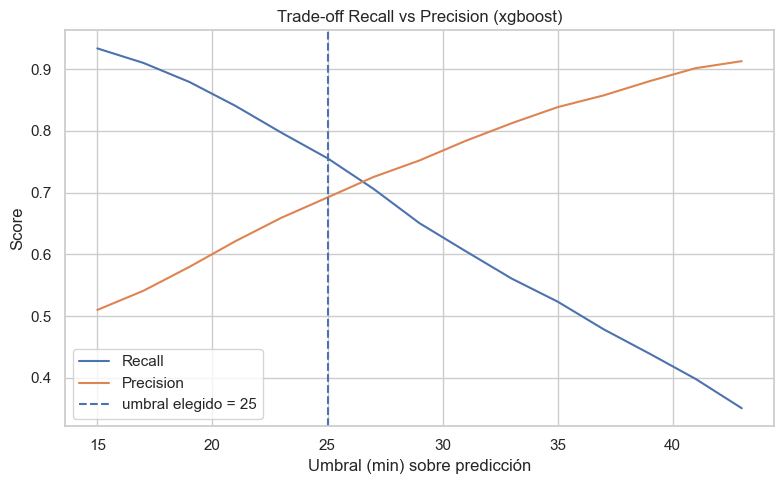

In [108]:
ensure_dir("outputs/figures")

plt.figure(figsize=(8,5))
plt.plot(grid["Umbral_pred"], grid["Recall"], label="Recall")
plt.plot(grid["Umbral_pred"], grid["Precision"], label="Precision")
plt.axvline(best_threshold, linestyle="--", label=f"umbral elegido = {best_threshold}")
plt.xlabel("Umbral (min) sobre predicción")
plt.ylabel("Score")
plt.title(f"Trade-off Recall vs Precision ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.savefig(f"outputs/figures/threshold_tradeoff_{best_model_name}.png", dpi=150)
plt.show()

### Impacto operacional

Comparando ambos escenarios:

**Umbral tradicional (30 min)**  
- Recall: ~0.62  
- Precision: ~0.77  
- Alertas generadas: 1864

**Umbral optimizado (25 min)**  
- Recall: ~0.76  
- Precision: ~0.69  
- Alertas generadas: 2510

Esto significa que el sistema podría **detectar significativamente más atrasos críticos** anticipadamente, a costa de generar un mayor número de alertas.

El cambio de umbral aumenta las alertas generadas en 646 casos, permitiendo detectar una mayor proporción de atrasos críticos.

In [34]:
def minutes_to_hhmmss(m):
    m = int(round(m)) % 1440
    h = m // 60
    mm = m % 60
    return f"{h:02d}:{mm:02d}:00"

### Priorización de operaciones con mayor riesgo

La siguiente tabla muestra un ejemplo de cómo el modelo puede utilizarse para priorizar operaciones con mayor probabilidad de atraso.

Cada fila representa una operación logística, donde se incluyen variables relevantes como la empresa, tipo de operación, tipo de carga y hora programada.

El modelo estima los **minutos de atraso esperados** y genera una **alerta crítica** cuando la predicción supera el umbral operativo definido.

Las operaciones se ordenan desde las más riesgosas hacia abajo, lo que permite identificar rápidamente qué casos deberían ser monitoreados o gestionados con mayor prioridad.

In [35]:
ensure_dir("outputs/tables")

prior = X_test.copy()
prior["minutos_reales"] = y_test.values
prior["minutos_predichos"] = pred_best
prior["alerta_critica"] = prior["minutos_predichos"] > best_threshold

#HH:MM:SS
prior["hora_programada"] = prior["hora_programada_min"].apply(minutes_to_hhmmss)

# Orden: primero los más riesgosos
prior = prior.sort_values(["alerta_critica", "minutos_predichos"], ascending=[False, False])

cols_final = [
    "empresa","patente","tipo_operacion","tipo_carga","semana",
    "hora_programada","minutos_predichos","alerta_critica"
]

prior_final = prior[cols_final].head(20)
prior_final

,empresa,patente,tipo_operacion,tipo_carga,semana,hora_programada,minutos_predichos,alerta_critica
29898,CumbreKargo 24,TRK-032,Despacho,Carga Suelta,7,18:16:00,87.511086,True
15442,VentiscaLine Transport,TRK-004,Recepcion,Pallet,8,23:46:00,85.964676,True
1998,CumbreKargo 24,TRK-068,Despacho,Carga Suelta,49,22:07:00,85.760361,True
32650,SendaKrio Operaciones,TRK-021,Recepcion,Pallet,15,23:13:00,84.942818,True
3508,CumbreKargo 24,TRK-018,Recepcion,Pallet,43,21:48:00,83.896103,True
19582,VentiscaLine Transport,TRK-056,Recepcion,Carga Suelta,4,18:42:00,83.889069,True
34962,CumbreKargo 24,TRK-002,Recepcion,Carga Suelta,43,18:35:00,80.930153,True
14598,CumbreKargo 24,TRK-059,Recepcion,Pallet,16,19:35:00,80.148994,True
5101,VentiscaLine Transport,TRK-055,Recepcion,Carga Suelta,42,20:33:00,79.926872,True
33934,VentiscaLine Transport,TRK-068,Despacho,Carga Suelta,32,23:53:00,79.480377,True


## Conclusiones

En este proyecto se desarrolló un modelo de *Machine Learning* para predecir atrasos en operaciones logísticas y generar alertas tempranas de posibles casos críticos.

El análisis exploratorio de datos permitió identificar patrones relevantes en el comportamiento de los atrasos. En particular, los gráficos por bloque horario y carga operacional muestran que los atrasos tienden a incrementarse durante las últimas horas del día, especialmente cuando aumenta la concentración de operaciones programadas. Esto sugiere que parte de los atrasos podría estar asociada a fenómenos de congestión operativa acumulada a lo largo de la jornada.

Tras evaluar distintos algoritmos de predicción, **XGBoost fue seleccionado como el modelo con mejor desempeño predictivo**, logrando estimar los minutos de atraso con un **error promedio cercano a 11–12 minutos**.

Posteriormente se optimizó el **umbral de alerta**, ajustándolo desde 30 a aproximadamente **25 minutos**, lo que permite detectar una mayor proporción de atrasos críticos y mejorar la capacidad del sistema para anticipar situaciones operacionales complejas.

Finalmente, el modelo permite generar una **priorización de operaciones con mayor riesgo de atraso**, lo que podría utilizarse como herramienta de monitoreo para apoyar la toma de decisiones en la gestión logística, identificando las operaciones que requieran atención prioritaria.